In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import os
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from statistics import mean
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data Folder_TE/Final FV/COMBINE FILE-FV/DATASET 1.csv')
x = df.sample(frac=1)
x.to_csv(('/content/drive/MyDrive/new.csv') , index=False)


In [ ]:
df

,FV1,FV2,FV3,FV4,FV5,FV6,FV7,FV8,FV9,FV10,...,FV513,FV514,FV515,FV516,FV517,FV518,FV519,FV520,FV521,CLASS-LABEL
0,9435,390011,21403639,1.322124e+09,388114,16089200,8.836494e+08,21059404,8.743913e+08,1.283313e+09,...,22238,23030,50479,58601,19065,44827,79167,68540,49574,0
1,7382,269056,12907222,6.947767e+08,262408,9636989,4.641328e+08,12306114,4.537181e+08,6.486750e+08,...,41690,28192,36238,53363,41552,31806,47496,24026,29215,0
2,12871,614235,38863801,2.766000e+09,612976,29255000,1.849606e+09,38602014,1.840405e+09,2.723398e+09,...,49066,22466,82149,74143,94185,147367,125748,74583,89820,0
3,13324,648284,41945426,3.050727e+09,655880,31797144,2.053901e+09,42577616,2.055764e+09,3.093700e+09,...,88021,65942,69451,115216,87660,115527,132444,61908,86592,0
4,8469,324438,16479440,9.419279e+08,323017,12380699,6.280145e+08,16494219,6.314446e+08,9.494133e+08,...,23949,5200,41667,96021,27451,71207,28045,28860,23865,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49036,326,2889,32787,4.179570e+05,2765,24065,2.700550e+05,31795,2.738050e+05,4.150130e+05,...,137,0,63,123,0,20,197,169,104,12
49037,307,2464,26108,3.151120e+05,2445,18894,1.978640e+05,24757,1.891440e+05,2.796690e+05,...,22,0,4,140,0,110,460,78,36,12
49038,980,16114,341026,8.058316e+06,14106,231269,4.880535e+06,272438,4.443689e+06,5.991174e+06,...,0,267,118,1528,40,369,1690,913,554,12
49039,2667,62303,1929959,6.715919e+07,59516,1384339,4.256264e+07,1764106,4.112920e+07,5.889945e+07,...,616,879,2686,4925,1225,4759,16804,8018,6835,12


In [ ]:
df1= pd.read_csv('/content/drive/MyDrive/new.csv')

In [ ]:
features= df1.drop(['CLASS-LABEL'], axis=1)
labels = df1['CLASS-LABEL']



**Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
features = features.apply(le.fit_transform)

In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE

smote = SMOTE()

features, labels = smote.fit_resample(features, labels)



In [ ]:
features.shape

(265902, 521)

**Standard Scaler For Features Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.get_params()
feature=scaler.fit_transform(features)

In [ ]:
feature.shape


(49041, 521)

In [ ]:
print(np.any(np.isinf(feature)))
print(np.any(np.isinf(labels)))


False
False


# **SELF CONSISTENCY TEST**

Self-Consistency Accuracy: 98.64%

Confusion Matrix:
 [[18835   511     0    12    12     0     3     2    13     0    33     0
   1033]
 [  557 18996     1     7    12     0     1     0    19     0    27     1
    833]
 [    0     0 20454     0     0     0     0     0     0     0     0     0
      0]
 [    1     1     0 20449     1     0     0     0     0     0     2     0
      0]
 [    3     2     0    10 20436     0     0     0     2     0     1     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     1 20453     0     0
      0]
 [    0     1     0     3     0     0     1     0     3     0 20444     1
      1]
 [    0     0     0     0     0  

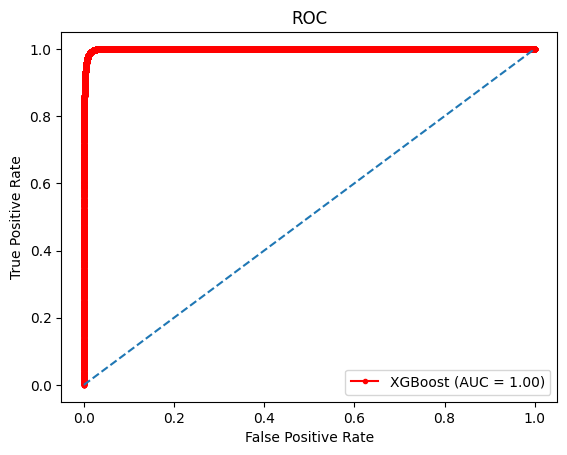

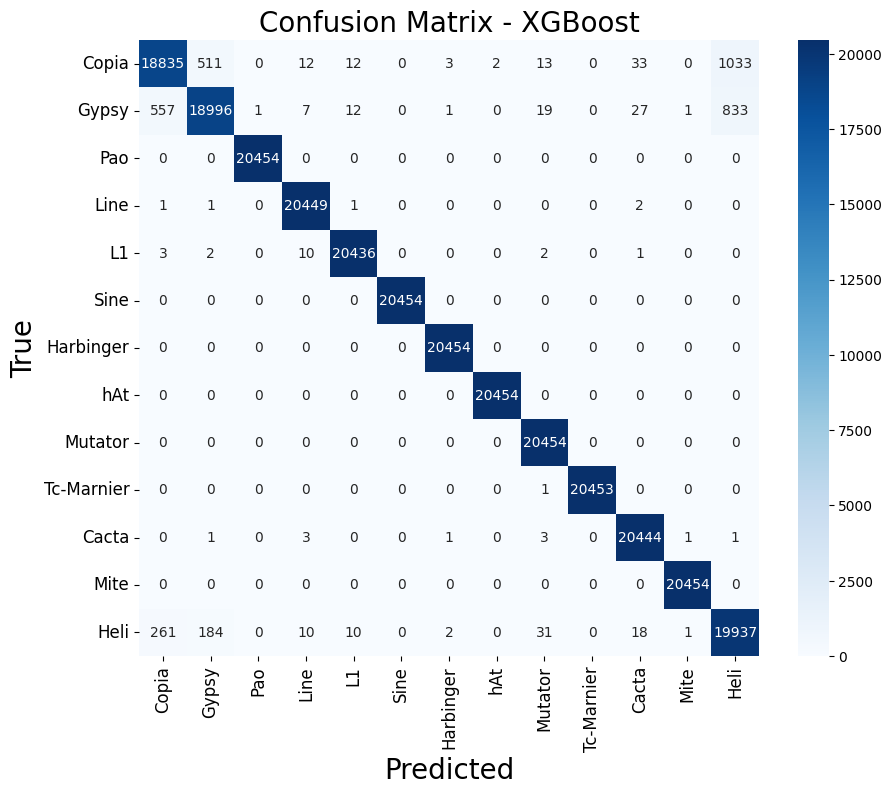

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
xgb_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
xgb_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = xgb_model.predict(feature)
pred_prob = xgb_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_xgb = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_xgb)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_xg = {}
tpr_xg = {}
thresh_xg ={}

n_class = 13

for i in range(n_class):
    fpr_xg[i], tpr_xg[i], thresh_xg[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_xg = auc(fpr_xg[i], tpr_xg[i])
roc_xg
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xg[i], tpr_xg[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xg)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-xgb_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 98.64%

Confusion Matrix:
 [[18835   511     0    12    12     0     3     2    13     0    33     0
   1033]
 [  557 18996     1     7    12     0     1     0    19     0    27     1
    833]
 [    0     0 20454     0     0     0     0     0     0     0     0     0
      0]
 [    1     1     0 20449     1     0     0     0     0     0     2     0
      0]
 [    3     2     0    10 20436     0     0     0     2     0     1     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     1 20453     0     0
      0]
 [    0     1     0     3     0     0     1     0     3     0 20444     1
      1]
 [    0     0     0     0     0  

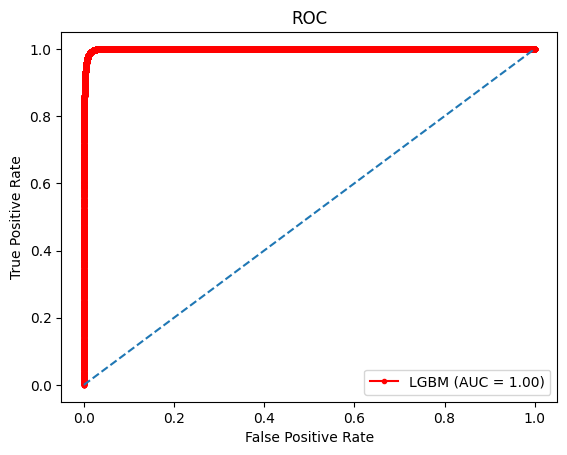

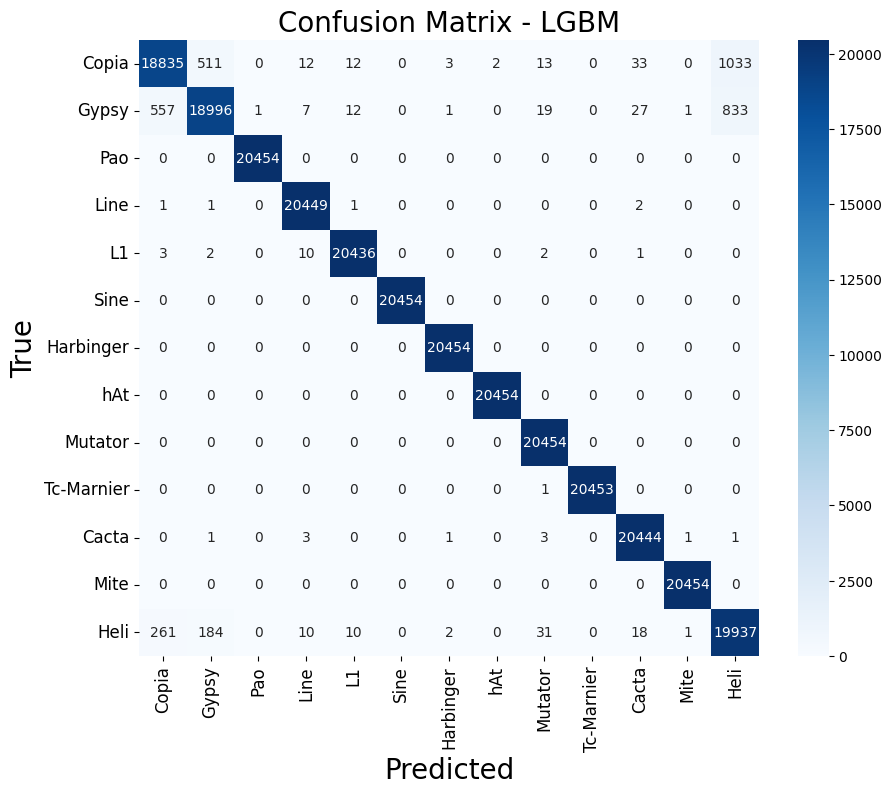

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
from lightgbm import LGBMClassifier

# ==============================
# Define optimized LightGBM model
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=100
)

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
lgbm_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
lgbm_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = lgbm_model.predict(feature)
pred_prob = lgbm_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_lgbm = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_lgbm)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_lgbm = {}
tpr_lgbm = {}
thresh_lgbm ={}


n_class = 13

for i in range(n_class):
    fpr_lgbm[i], tpr_lgbm[i], thresh_lgbm[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_lgbm = auc(fpr_lgbm[i], tpr_lgbm[i])
roc_lgbm
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm[i], tpr_lgbm[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-lgbm_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.96%

Confusion Matrix:
 [[20424    14     0     0     0     0     0     0     0     0     0     0
     16]
 [   36 20394     1     1     0     0     1     0     1     0     1     0
     19]
 [    0     1 20453     0     0     0     0     0     0     0     0     0
      0]
 [    0     0     0 20454     0     0     0     0     0     0     0     0
      0]
 [    0     1     0     2 20451     0     0     0     0     0     0     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     0 20454     0     0
      0]
 [    0     0     0     0     0     0     0     0     0     0 20454     0
      0]
 [    0     0     0     0     0  

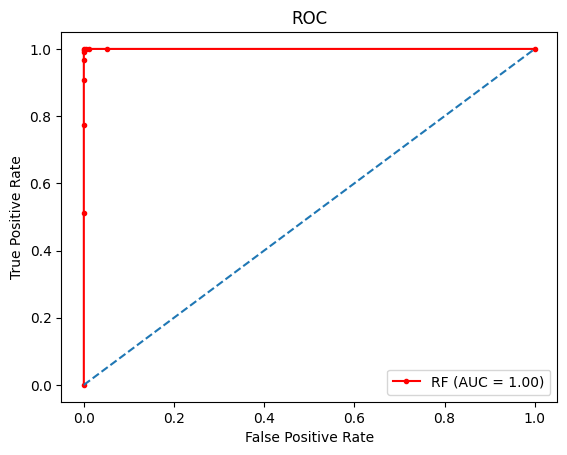

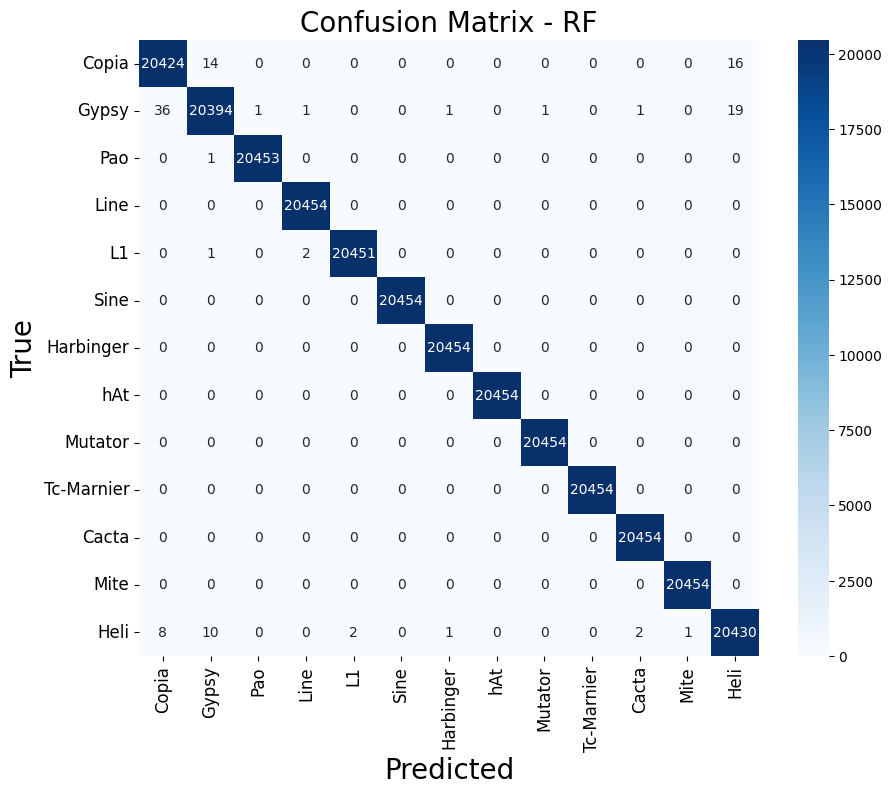

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    matthews_corrcoef, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ==============================
# Define Random Forest model
# ==============================
rf_model = RandomForestClassifier(n_estimators=10, random_state=10)
# ==============================
# Train on ALL data (self-consistency)
# ==============================
rf_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = rf_model.predict(feature)
pred_prob = rf_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_rf = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_rf)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_rf = {}
tpr_rf = {}
thresh_rf ={}


n_class = 13

for i in range(n_class):
    fpr_rf[i], tpr_rf[i], thresh_rf[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf = auc(fpr_rf[i], tpr_rf[i])
roc_rf
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rf[i], tpr_rf[i], marker='.', color='red',
         label='RF (AUC = %0.2f)' % roc_rf)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-rf_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - RF', fontsize=20)

# Save & show
plt.savefig('rf_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 100.00%

Confusion Matrix:
 [[20454     0     0     0     0     0     0     0     0     0     0     0
      0]
 [    1 20453     0     0     0     0     0     0     0     0     0     0
      0]
 [    0     0 20454     0     0     0     0     0     0     0     0     0
      0]
 [    0     0     0 20454     0     0     0     0     0     0     0     0
      0]
 [    0     0     0     0 20454     0     0     0     0     0     0     0
      0]
 [    0     0     0     0     0 20454     0     0     0     0     0     0
      0]
 [    0     0     0     0     0     0 20454     0     0     0     0     0
      0]
 [    0     0     0     0     0     0     0 20454     0     0     0     0
      0]
 [    0     0     0     0     0     0     0     0 20454     0     0     0
      0]
 [    0     0     0     0     0     0     0     0     0 20454     0     0
      0]
 [    0     0     0     0     0     0     0     0     0     0 20454     0
      0]
 [    0     0     0     0     0 

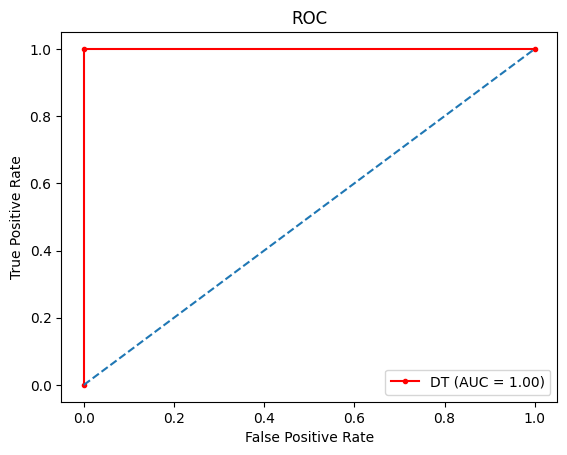

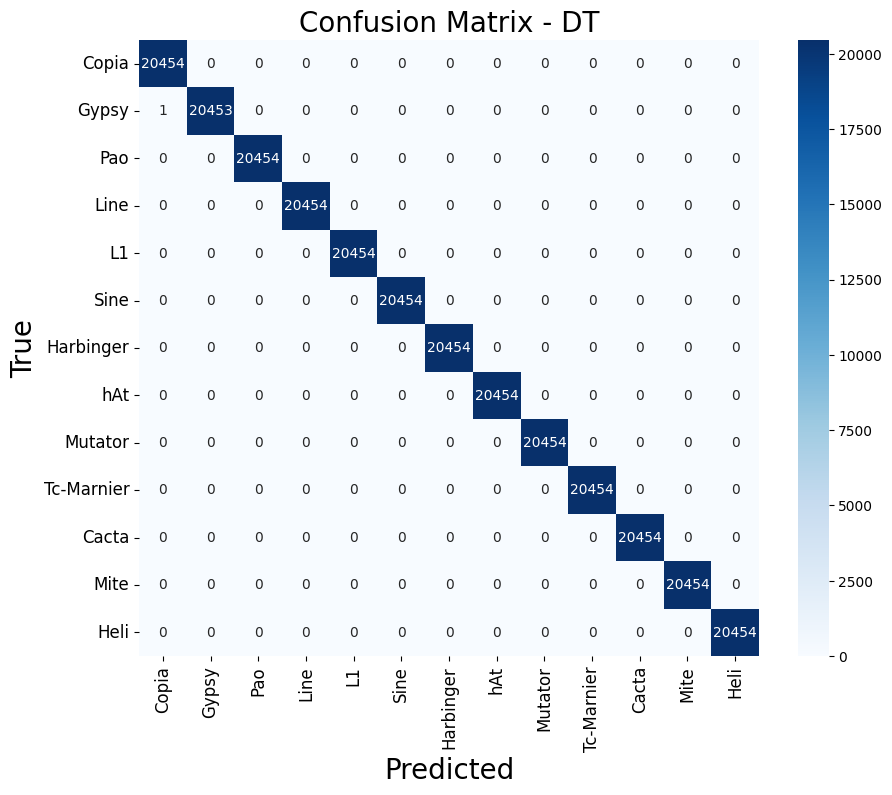

In [ ]:
 dt_model = DecisionTreeClassifier()
# train the model using X_train_dtm & y_train

# ==============================
# Train on ALL data (self-consistency)
# ==============================
dt_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = dt_model.predict(feature)
pred_prob = dt_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_dt = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_dt)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_dt = {}
tpr_dt = {}
thresh_dt ={}


n_class = 13

for i in range(n_class):
    fpr_dt[i], tpr_dt[i], thresh_dt[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_dt = auc(fpr_dt[i], tpr_dt[i])
roc_dt
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt[i], tpr_dt[i], marker='.', color='red',
         label='DT (AUC = %0.2f)' % roc_dt)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-dt_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - DT', fontsize=20)

# Save & show
plt.savefig('dt_self-test_cm.png')
plt.show()


# **ROC-SELF TEST**

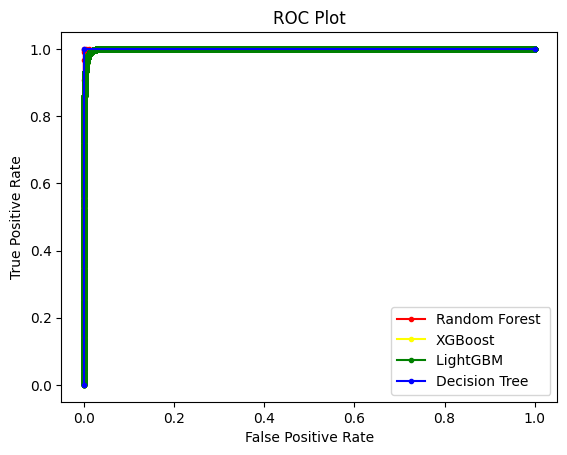

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf[i],tpr_rf[i], marker='.',color='red',label = 'Random Forest ' % roc_rf)
plt.plot(fpr_xg[i],tpr_xg[i], marker='.',color='yellow',label = 'XGBoost' % roc_xg)
plt.plot(fpr_lgbm[i],tpr_lgbm[i], marker='.',color='green',label = 'LightGBM ' % roc_lgbm)
plt.plot(fpr_dt[i],tpr_dt[i], marker='.',color='blue',label = 'Decision Tree' % roc_dt)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('self-test_roc.png')
# Show plot
plt.show()


#  **Independent Set Testing (Train Test Split)**    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=100,stratify=labels)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(186131, 521) (79771, 521)
(186131,) (79771,)


Training accuracy is 0.9898727240491911
Test accuracy is 0.9680836394178336
[[5116  390    1   27   31    1    1   10   20    0   31    4  504]
 [ 333 5201    6   21   34    0    4    0   25    4   40    7  461]
 [   1    0 6132    0    0    0    0    0    0    0    0    0    3]
 [   1    6    0 6111   11    0    1    0    1    1    3    0    2]
 [   7    9    0   29 6078    0    3    0    4    0    2    1    3]
 [   0    0    0    1    1 6134    0    0    0    0    0    0    0]
 [   0    0    0    0    1    0 6131    0    2    0    0    0    2]
 [   1    4    0    0    0    0    0 6126    3    0    0    1    1]
 [   2    2    0    0    0    0    1    0 6129    0    1    0    2]
 [   0    0    0    3    0    0    0    0    2 6129    2    0    0]
 [   0    5    0    4    0    0    2    0    7    6 6108    1    3]
 [   0    0    0    0    0    0    0    0    0    0    0 6136    0]
 [ 155  168    0   23   19    0    5    4   34    5   16   14 5694]]
              precision    recall  f1-s

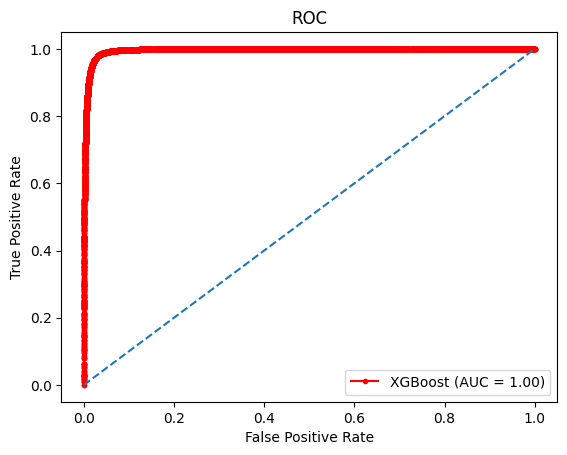

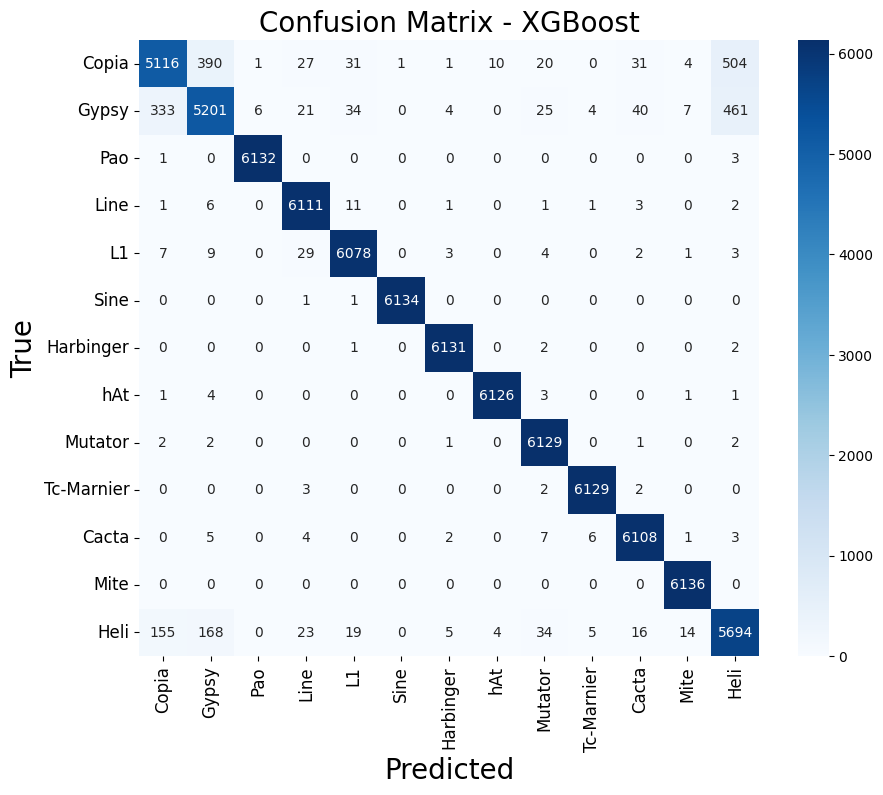

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef
xgb1 = XGBClassifier(n_estimators=100)
xgb1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = xgb1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = xgb1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = xgb1.predict_proba(X_test)

cm_xgb1 = confusion_matrix(y_test, y_pred_test)
print(cm_xgb1)

cr_xgb1 = classification_report(y_test, y_pred_test)
print(cr_xgb1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_xgb1[0,0] / (cm_xgb1[0,0] + cm_xgb1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb1[1,1] / (cm_xgb1[1,0] + cm_xgb1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_xgb1 = {}
tpr_xgb1 = {}
thresh_xgb1 = {}

n_class = 13

for i in range(n_class):
    fpr_xgb1[i], tpr_xgb1[i], thresh_xgb1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_xgb1 = auc(fpr_xgb1[i], tpr_xgb1[i])

roc_xgb1
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xgb1[i], tpr_xgb1[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-xgb1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9993552927776673
Test accuracy is 0.960186032518083
[[5171  449    3   34   49    1   14    6   13    4   33    6  353]
 [ 544 4934    8   43   75    2    4    7   33    2   64   11  409]
 [  15    6 6103    0    2    0    0    0    1    0    1    0    8]
 [   3    5    2 6105    4    1    1    1    5    3    3    3    1]
 [  36   20    2   33 6033    1    1    1    2    0    0    4    3]
 [   0    0    0    0    0 6135    1    0    0    0    0    0    0]
 [   0    0    0    4    0    0 6131    1    0    0    0    0    0]
 [   2    4    0    2    4    0    0 6118    0    0    1    0    5]
 [   4    1    0    8    1    0    0    0 6118    0    3    1    1]
 [   4    4    0    4    1    3    2    0    5 6100    4    5    4]
 [   3   10    0    8    2    4    2    0    3   10 6084    1    9]
 [   0    0    0    7    1    1    4    0    3    1    1 6117    1]
 [ 220  268    2   39   28    6   14    6   25   16   24   43 5446]]
              precision    recall  f1-sc

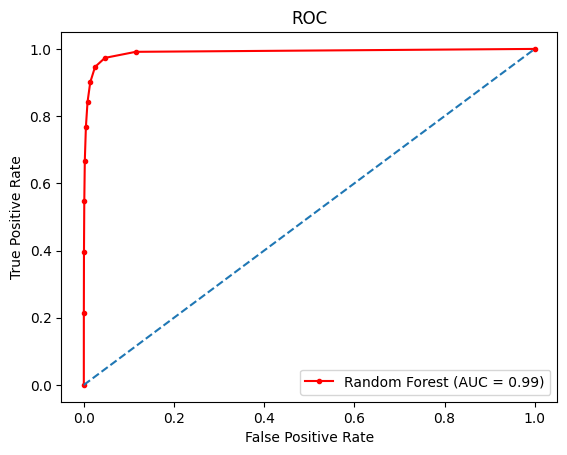

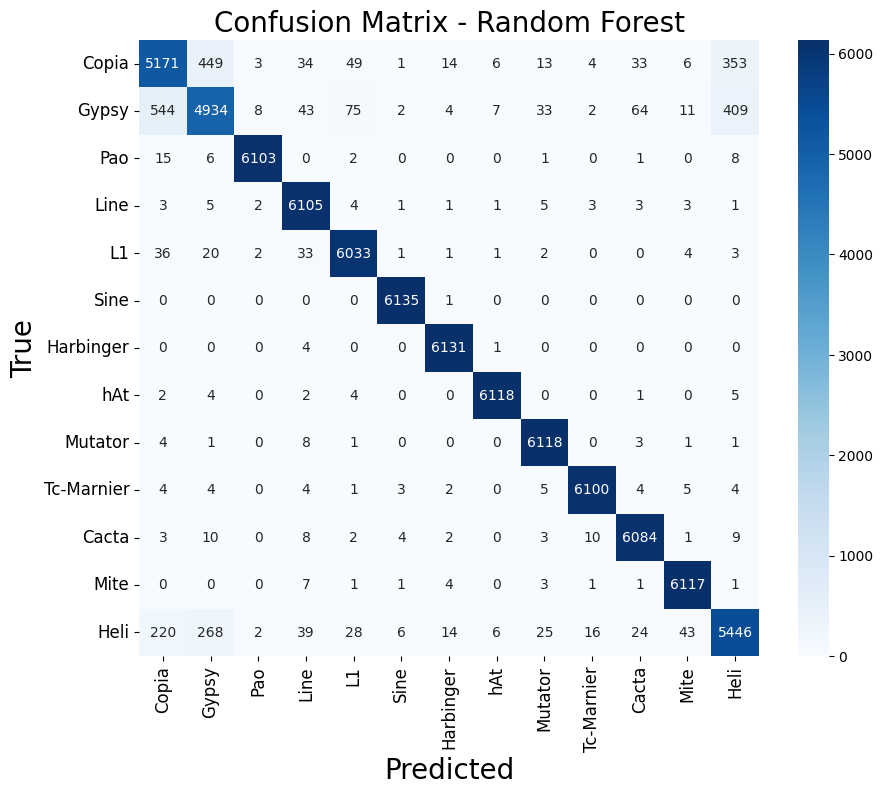

In [ ]:
rclf1 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf1.fit(X_train, y_train)
rclf1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = rclf1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = rclf1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = rclf1.predict_proba(X_test)

cm_rclf1 = confusion_matrix(y_test, y_pred_test)
print(cm_rclf1)

cr_rclf1 = classification_report(y_test, y_pred_test)
print(cr_rclf1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_rclf1[0,0] / (cm_rclf1[0,0] + cm_rclf1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_rclf1[1,1] / (cm_rclf1[1,0] + cm_rclf1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_rclf1 = {}
tpr_rclf1 = {}
thresh_rclf1 = {}

n_class = 13

for i in range(n_class):
    fpr_rclf1[i], tpr_rclf1[i], thresh_rclf1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_rclf1 = auc(fpr_rclf1[i], tpr_rclf1[i])

roc_rclf1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rclf1[i], tpr_rclf1[i], marker='.', color='red',
         label='Random Forest (AUC = %0.2f)' % roc_rclf1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-rclf1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show
plt.savefig('rclf1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9999946274398139
Test accuracy is 0.9134397212019405
[[4649  511   50   44  170    3   25   33   55   14   93   19  470]
 [ 628 4283   66   67  129    2   31   41  123   12  171   39  544]
 [  30   32 6033    2    5    0    0    0    5    0    4    1   24]
 [  27   54    4 5689   63   41   44   24   25   55   31   52   28]
 [  96   81    4   74 5714    8   32   15   16    9   27   20   40]
 [   2    2    0   24    4 6040    8    7   11    7    3   24    4]
 [   9    8    0   31   15   11 5962    8   26   18   12   28    8]
 [  10   16    0   13   12   11    6 6034    8    3    9    4   10]
 [  19   33    4   25   20   12   13   17 5915    4   23   40   12]
 [   7    8    2   32   18    7   17    3   11 5965    9   42   15]
 [  43   57    4   30   10    6   11   11   26   23 5851   14   50]
 [  11   17    0   57   23   39   30   17   47   37   18 5809   31]
 [ 380  412   54   55   48    1   32   37   51   20   69   56 4922]]
              precision    recall  f1-s

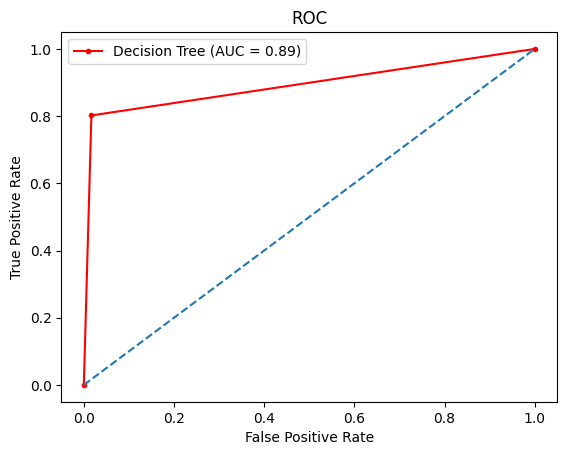

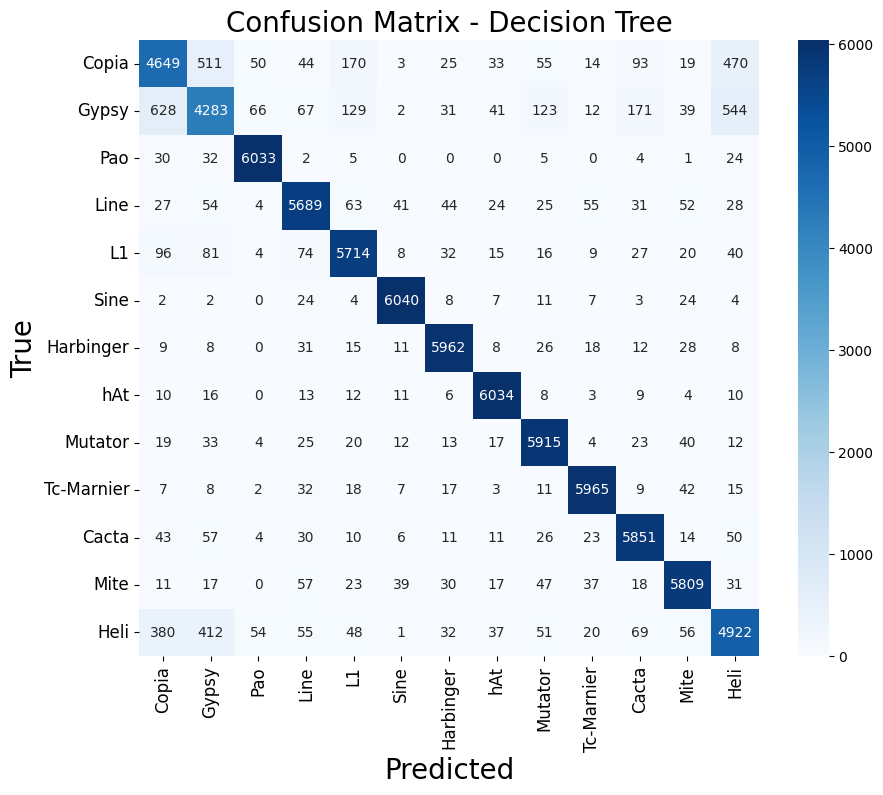

In [ ]:
dt1 = DecisionTreeClassifier()
dt1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = dt1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = dt1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = dt1.predict_proba(X_test)

cm_dt1 = confusion_matrix(y_test, y_pred_test)
print(cm_dt1)

cr_dt1 = classification_report(y_test, y_pred_test)
print(cr_dt1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_dt1[0,0] / (cm_dt1[0,0] + cm_dt1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt1[1,1] / (cm_dt1[1,0] + cm_dt1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_dt1 = {}
tpr_dt1 = {}
thresh_dt1 = {}

n_class = 13

for i in range(n_class):
    fpr_dt1[i], tpr_dt1[i], thresh_dt1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_dt1 = auc(fpr_dt1[i], tpr_dt1[i])

roc_dt1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt1[i], tpr_dt1[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-dt1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

# Save & show
plt.savefig('dt1_indep-test_cm.png')
plt.show()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.284243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 128187
[LightGBM] [Info] Number of data points in the train set: 186131, number of used features: 516
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.565003
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.565003
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.564933
[LightGBM] [Info] Start training from score -2.565003
Train

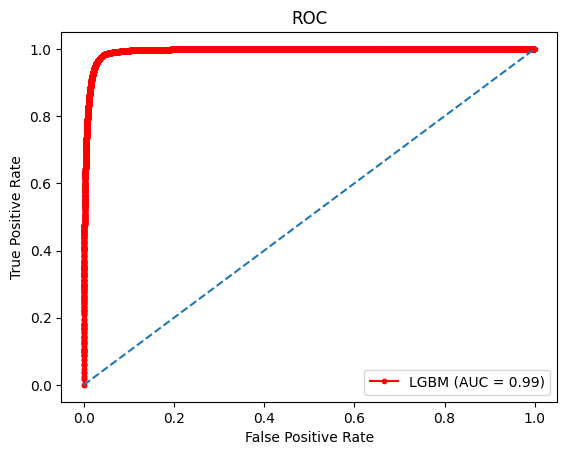

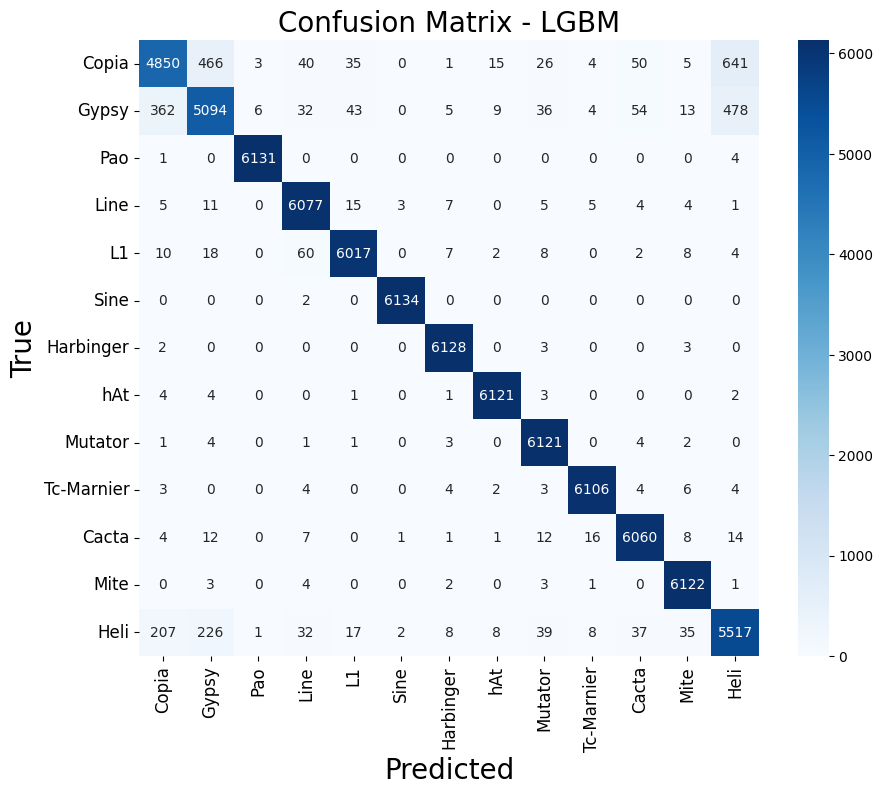

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from lightgbm import LGBMClassifier

lgbm1 = LGBMClassifier(
    n_estimators=100
)

lgbm1.fit(X_train, y_train)

# compute the training accuracy
y_pred_train = lgbm1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = lgbm1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = lgbm1.predict_proba(X_test)

cm_lgbm1 = confusion_matrix(y_test, y_pred_test)
print(cm_lgbm1)

cr_lgbm1 = classification_report(y_test, y_pred_test)
print(cr_lgbm1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_lgbm1[0,0] / (cm_lgbm1[0,0] + cm_lgbm1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm1[1,1] / (cm_lgbm1[1,0] + cm_lgbm1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_lgbm1 = {}
tpr_lgbm1 = {}
thresh_lgbm1 = {}

n_class = 13

for i in range(n_class):
    fpr_lgbm1[i], tpr_lgbm1[i], thresh_lgbm1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_lgbm1 = auc(fpr_lgbm1[i], tpr_lgbm1[i])

roc_lgbm1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm1[i], tpr_lgbm1[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-lgbm1_roc.png')
# Show plot
plt.show()


### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
               'hAt','Mutator','Tc-Marnier','Cacta','Mite','Heli']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm1_indep-test_cm.png')
plt.show()


**ROC-INDEPENDENT TEST**

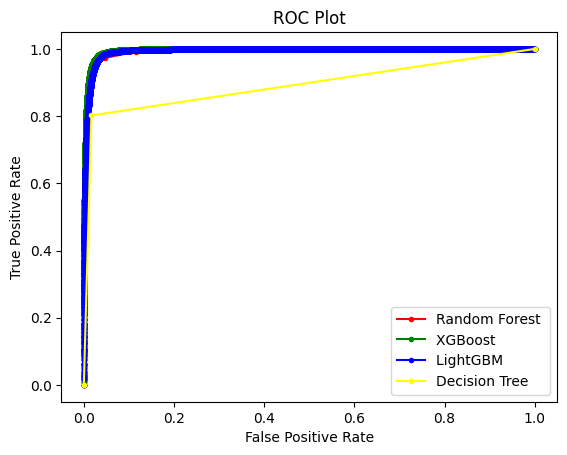

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rclf1[i],tpr_rclf1[i], marker='.',color='red',label = 'Random Forest ' % roc_rclf1)
plt.plot(fpr_xgb1[i],tpr_xgb1[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb1)
plt.plot(fpr_lgbm1[i],tpr_lgbm1[i], marker='.',color='blue',label = 'LightGBM ' % roc_lgbm1)
plt.plot(fpr_dt1[i],tpr_dt1[i], marker='.',color='yellow',label = 'Decision Tree ' % roc_dt1)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('INDE-test_roc.png')
# Show plot
plt.show()


# **Cross Validation Test**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef

Random Forest – 10-Fold Cross-Validation Results
Accuracy    : 0.784 ± 0.003
MCC         : 0.698 ± 0.004
Sensitivity : 0.630 ± 0.012
Specificity : 0.976 ± 0.000


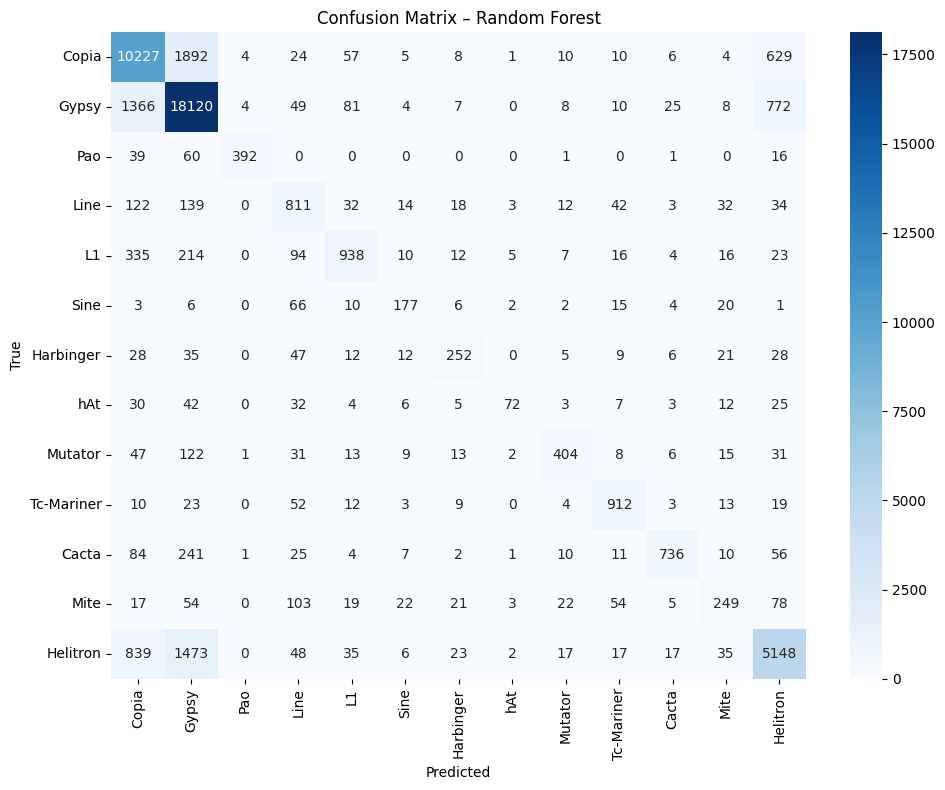

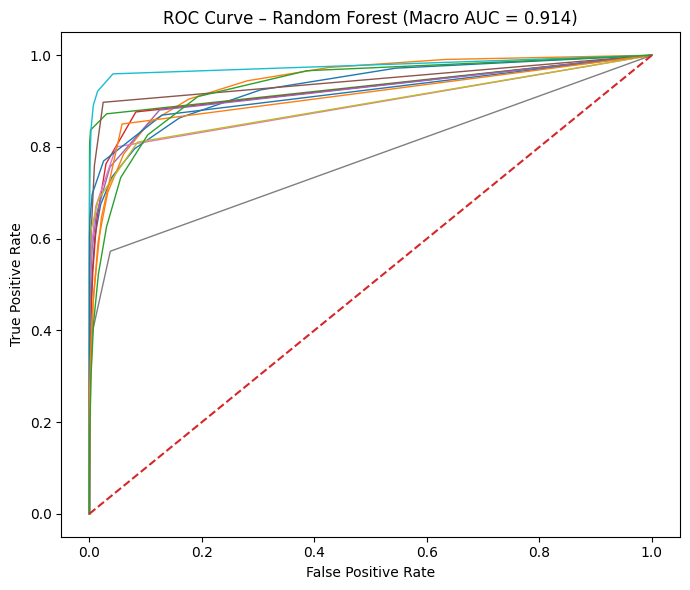

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------------------------
# Configuration
# -------------------------------------------------
n_splits = 10
n_classes = 13   # change to 4 for order-level classification

class_names = [
    'Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
    'hAt','Mutator','Tc-Mariner','Cacta','Mite','Helitron'
]

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------------------------
# Storage (saved for later statistical tests & ROC)
# -------------------------------------------------
rf_acc_scores = []
rf_mcc_scores = []
rf_sen_scores = []
rf_spe_scores = []

rf_y_true_all = []
rf_y_pred_all = []
rf_y_prob_all = []

# -------------------------------------------------
# Cross-validation loop
# -------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    rf = RandomForestClassifier(
        n_estimators=10,
        random_state=10
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)

    # Save predictions for global CM & ROC
    rf_y_true_all.append(y_test)
    rf_y_pred_all.append(y_pred)
    rf_y_prob_all.append(y_prob)

    # Accuracy
    rf_acc_scores.append(
        accuracy_score(y_test, y_pred)
    )

    # MCC (multiclass)
    rf_mcc_scores.append(
        matthews_corrcoef(y_test, y_pred)
    )

    # Sensitivity (macro recall)
    rf_sen_scores.append(
        recall_score(y_test, y_pred, average='macro')
    )

    # Specificity (macro)
    cm = confusion_matrix(y_test, y_pred)
    spec_per_class = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec_per_class.append(tn / (tn + fp))

    rf_spe_scores.append(np.mean(spec_per_class))

# -------------------------------------------------
# Merge predictions from all folds
# -------------------------------------------------
y_true = np.concatenate(rf_y_true_all)
y_pred = np.concatenate(rf_y_pred_all)
y_prob = np.vstack(rf_y_prob_all)

# -------------------------------------------------
# Cross-validation performance summary
# -------------------------------------------------
print("Random Forest – 10-Fold Cross-Validation Results")
print(f"Accuracy    : {np.mean(rf_acc_scores):.3f} ± {np.std(rf_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(rf_mcc_scores):.3f} ± {np.std(rf_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(rf_sen_scores):.3f} ± {np.std(rf_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(rf_spe_scores):.3f} ± {np.std(rf_spe_scores, ddof=1):.3f}")

# -------------------------------------------------
# Confusion Matrix (cross-validated)
# -------------------------------------------------
cm_rf = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='g',
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Random Forest")
plt.tight_layout()
plt.savefig("rf_crossval_cm.png", dpi=600)
plt.show()

# -------------------------------------------------
# ROC Curve (One-vs-Rest, macro-averaged)
# -------------------------------------------------
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr = {}
tpr = {}
roc_auc = []

plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc.append(auc(fpr[i], tpr[i]))
    plt.plot(fpr[i], tpr[i], lw=1)

macro_auc = np.mean(roc_auc)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title(f"ROC Curve – Random Forest (Macro AUC = {macro_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("rf_crossval_roc.png", dpi=600)
plt.show()

# -------------------------------------------------
# Save results for later comparison (t-test & ROC)
# -------------------------------------------------
rf_results = {
    "mcc_scores": rf_mcc_scores,      # for paired t-test
    "accuracy_scores": rf_acc_scores,
    "macro_auc": macro_auc,
    "mean_mcc": np.mean(rf_mcc_scores),
    "std_mcc": np.std(rf_mcc_scores, ddof=1)
}


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 65.0 MB/s eta 0:00:00
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061845 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127856
[LightGBM] [Info] Number of data points in the train set: 44136, number of used features: 516
[LightGBM] [Info] Start training from score -1.337219
[LightGBM] [Info] Start training from score -0.874490
[LightGBM] [Info] Start training from score -4.568162
[LightGBM] [Info] Start training from score -3.659762
[LightGBM] [Info] Start training from score -3.377155
[LightGBM] [Info] Start training from score -5.060241
[LightGBM] [Info] Start training from score -4.678874
[LightGBM] [Info] Start training from score -5.315134
[LightGBM] [Info] Start training from score -4.246142
[LightGBM] [Info] Start training from score -3.834367
[LightGBM] [Info] Start training from score -3.720552
[LightGBM] [Info] Start training from

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127872
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -1.337242
[LightGBM] [Info] Start training from score -0.874513
[LightGBM] [Info] Start training from score -4.568185
[LightGBM] [Info] Start training from score -3.659785
[LightGBM] [Info] Start training from score -3.377178
[LightGBM] [Info] Start training from score -5.056699
[LightGBM] [Info] Start training from score -4.678897
[LightGBM] [Info] Start training from score -5.315156
[LightGBM] [Info] Start training from score -4.246164
[LightGBM] [Info] Start training from score -3.834390
[LightGBM] [Info] Start training from score -3.720575
[LightGBM] [Info] Start training from score -4.328583
[LightGBM] [Info] Start training from score -1.856647


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.066250 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127818
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -1.337242
[LightGBM] [Info] Start training from score -0.874513
[LightGBM] [Info] Start training from score -4.568185
[LightGBM] [Info] Start training from score -3.660666
[LightGBM] [Info] Start training from score -3.377178
[LightGBM] [Info] Start training from score -5.056699
[LightGBM] [Info] Start training from score -4.678897
[LightGBM] [Info] Start training from score -5.315156
[LightGBM] [Info] Start training from score -4.246164
[LightGBM] [Info] Start training from score -3.834390
[LightGBM] [Info] Start training from score -3.720575
[LightGBM] [Info] Start training from score -4.326867
[LightGBM] [Info] Start training from score -1.856647


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069932 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127833
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -1.337242
[LightGBM] [Info] Start training from score -0.874459
[LightGBM] [Info] Start training from score -4.566004
[LightGBM] [Info] Start training from score -3.659785
[LightGBM] [Info] Start training from score -3.377178
[LightGBM] [Info] Start training from score -5.056699
[LightGBM] [Info] Start training from score -4.681339
[LightGBM] [Info] Start training from score -5.319775
[LightGBM] [Info] Start training from score -4.246164
[LightGBM] [Info] Start training from score -3.834390
[LightGBM] [Info] Start training from score -3.720575
[LightGBM] [Info] Start training from score -4.328583
[LightGBM] [Info] Start training from score -1.856647


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127853
[LightGBM] [Info] Number of data points in the train set: 44137, number of used features: 516
[LightGBM] [Info] Start training from score -1.337242
[LightGBM] [Info] Start training from score -0.874459
[LightGBM] [Info] Start training from score -4.568185
[LightGBM] [Info] Start training from score -3.659785
[LightGBM] [Info] Start training from score -3.377178
[LightGBM] [Info] Start training from score -5.060264
[LightGBM] [Info] Start training from score -4.678897
[LightGBM] [Info] Start training from score -5.315156
[LightGBM] [Info] Start training from score -4.246164
[LightGBM] [Info] Start training from score -3.834390
[LightGBM] [Info] Start training from score -3.720575
[LightGBM] [Info] Start training from score -4.328583
[LightGBM] [Info] Start training from score -1.856647


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM – 10-Fold Cross-Validation Results
Accuracy    : 0.814 ± 0.005
MCC         : 0.743 ± 0.007
Sensitivity : 0.691 ± 0.014
Specificity : 0.980 ± 0.000


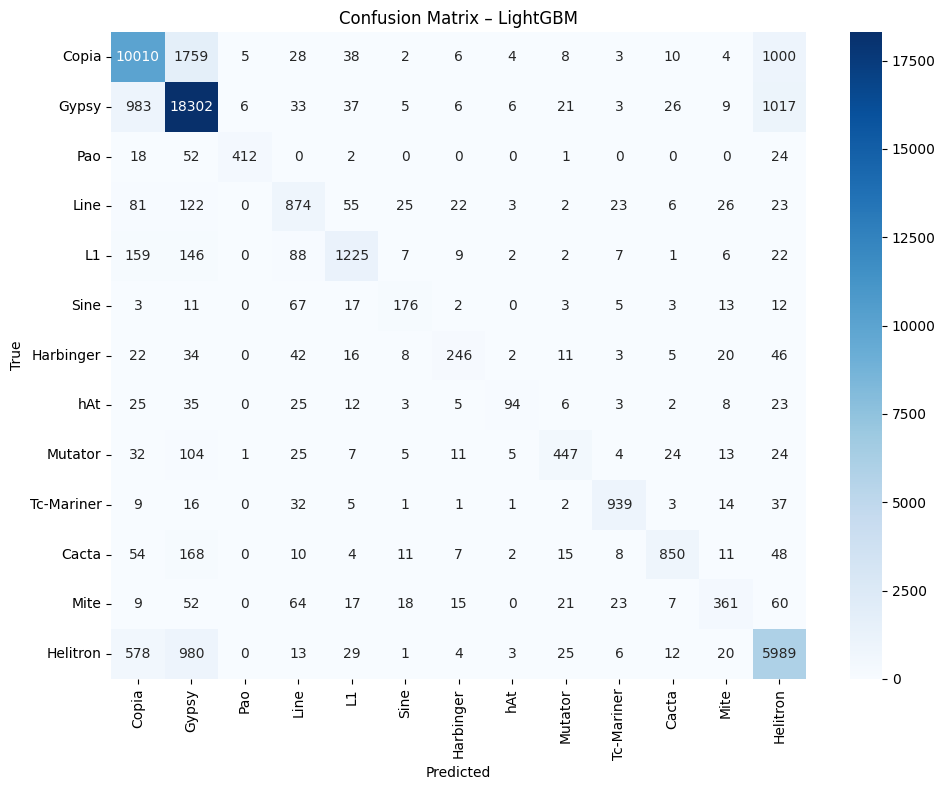

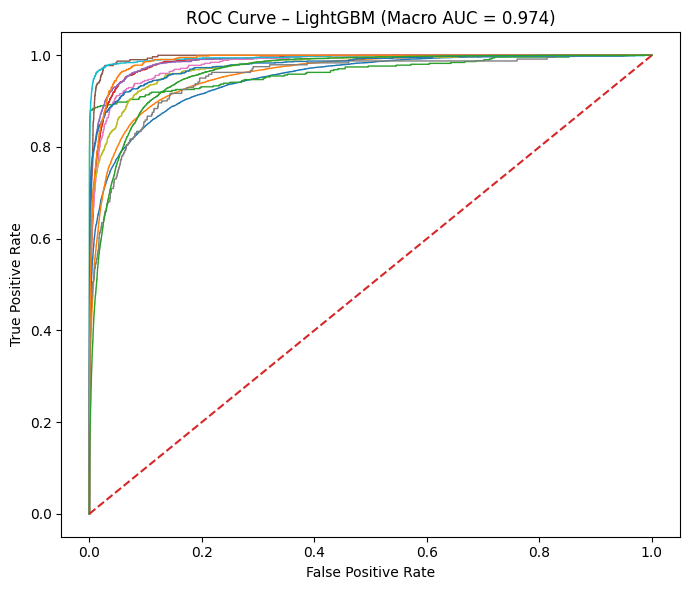

In [ ]:
!pip install lightgbm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------------------------
# Configuration
# -------------------------------------------------
n_splits = 10
n_classes = 13   # change to 4 for order-level classification

class_names = [
    'Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
    'hAt','Mutator','Tc-Mariner','Cacta','Mite','Helitron'
]

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------------------------
# Storage (saved for later statistical tests & ROC)
# -------------------------------------------------
lgbm_acc_scores = []
lgbm_mcc_scores = []
lgbm_sen_scores = []
lgbm_spe_scores = []

lgbm_y_true_all = []
lgbm_y_pred_all = []
lgbm_y_prob_all = []

# -------------------------------------------------
# Cross-validation loop
# -------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    lgbm = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42
    )

    lgbm.fit(X_train, y_train)

    y_pred = lgbm.predict(X_test)
    y_prob = lgbm.predict_proba(X_test)

    # Save predictions for global CM & ROC
    lgbm_y_true_all.append(y_test)
    lgbm_y_pred_all.append(y_pred)
    lgbm_y_prob_all.append(y_prob)

    # Accuracy
    lgbm_acc_scores.append(
        accuracy_score(y_test, y_pred)
    )

    # MCC (multiclass)
    lgbm_mcc_scores.append(
        matthews_corrcoef(y_test, y_pred)
    )

    # Sensitivity (macro recall)
    lgbm_sen_scores.append(
        recall_score(y_test, y_pred, average='macro')
    )

    # Specificity (macro)
    cm = confusion_matrix(y_test, y_pred)
    spec_per_class = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec_per_class.append(tn / (tn + fp))

    lgbm_spe_scores.append(np.mean(spec_per_class))

# -------------------------------------------------
# Merge predictions from all folds
# -------------------------------------------------
y_true = np.concatenate(lgbm_y_true_all)
y_pred = np.concatenate(lgbm_y_pred_all)
y_prob = np.vstack(lgbm_y_prob_all)

# -------------------------------------------------
# Cross-validation performance summary
# -------------------------------------------------
print("LightGBM – 10-Fold Cross-Validation Results")
print(f"Accuracy    : {np.mean(lgbm_acc_scores):.3f} ± {np.std(lgbm_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(lgbm_mcc_scores):.3f} ± {np.std(lgbm_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(lgbm_sen_scores):.3f} ± {np.std(lgbm_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(lgbm_spe_scores):.3f} ± {np.std(lgbm_spe_scores, ddof=1):.3f}")

# -------------------------------------------------
# Confusion Matrix (cross-validated)
# -------------------------------------------------
cm_lgbm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt='g',
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – LightGBM")
plt.tight_layout()
plt.savefig("lgbm_crossval_cm.png", dpi=600)
plt.show()

# -------------------------------------------------
# ROC Curve (One-vs-Rest, macro-averaged)
# -------------------------------------------------
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

fpr = {}
tpr = {}
roc_auc = []

plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc.append(auc(fpr[i], tpr[i]))
    plt.plot(fpr[i], tpr[i], lw=1)

macro_auc = np.mean(roc_auc)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title(f"ROC Curve – LightGBM (Macro AUC = {macro_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("lgbm_crossval_roc.png", dpi=600)
plt.show()

# -------------------------------------------------
# Save results for later comparison (t-test & ROC)
# -------------------------------------------------
lgbm_results = {
    "mcc_scores": lgbm_mcc_scores,      # for paired t-test
    "accuracy_scores": lgbm_acc_scores,
    "macro_auc": macro_auc,
    "mean_mcc": np.mean(lgbm_mcc_scores),
    "std_mcc": np.std(lgbm_mcc_scores, ddof=1)
}


In [23]:
!pip install xgboost
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------------------------
# Configuration
# -------------------------------------------------
n_splits = 10
n_classes = 13   # change to 4 for order-level

class_names = [
    'Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
    'hAt','Mutator','Tc-Mariner','Cacta','Mite','Helitron'
]

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------------------------
# Storage (for t-test & ROC comparison)
# -------------------------------------------------
xgb_acc_scores = []
xgb_mcc_scores = []
xgb_sen_scores = []
xgb_spe_scores = []

xgb_y_true_all = []
xgb_y_pred_all = []
xgb_y_prob_all = []

# -------------------------------------------------
# Cross-validation loop
# -------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42
    )

    xgb.fit(X_train, y_train)

    y_pred = xgb.predict(X_test)
    y_prob = xgb.predict_proba(X_test)

    xgb_y_true_all.append(y_test)
    xgb_y_pred_all.append(y_pred)
    xgb_y_prob_all.append(y_prob)

    # Accuracy
    xgb_acc_scores.append(
        accuracy_score(y_test, y_pred)
    )

    # MCC (multiclass)
    xgb_mcc_scores.append(
        matthews_corrcoef(y_test, y_pred)
    )

    # Sensitivity (macro recall)
    xgb_sen_scores.append(
        recall_score(y_test, y_pred, average='macro')
    )

    # Specificity (macro)
    cm = confusion_matrix(y_test, y_pred)
    spec = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec.append(tn / (tn + fp))

    xgb_spe_scores.append(np.mean(spec))

# -------------------------------------------------
# Merge all folds
# -------------------------------------------------
y_true = np.concatenate(xgb_y_true_all)
y_pred = np.concatenate(xgb_y_pred_all)
y_prob = np.vstack(xgb_y_prob_all)

# -------------------------------------------------
# Performance summary
# -------------------------------------------------
print("XGBoost – 10-Fold Cross-Validation Results")
print(f"Accuracy    : {np.mean(xgb_acc_scores):.3f} ± {np.std(xgb_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(xgb_mcc_scores):.3f} ± {np.std(xgb_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(xgb_sen_scores):.3f} ± {np.std(xgb_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(xgb_spe_scores):.3f} ± {np.std(xgb_spe_scores, ddof=1):.3f}")

# -------------------------------------------------
# Confusion Matrix
# -------------------------------------------------
cm_xgb = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_xgb, annot=True, fmt='g', cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – XGBoost")
plt.tight_layout()
plt.savefig("xgb_crossval_cm.png", dpi=600)
plt.show()

# -------------------------------------------------
# ROC Curve (OvR)
# -------------------------------------------------
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

roc_auc = []
plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc.append(auc(fpr, tpr))
    plt.plot(fpr, tpr, lw=1)

macro_auc_xgb = np.mean(roc_auc)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title(f"ROC Curve – XGBoost (Macro AUC = {macro_auc_xgb:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("xgb_crossval_roc.png", dpi=600)
plt.show()

# -------------------------------------------------
# Save for statistical testing
# -------------------------------------------------
xgb_results = {
    "mcc_scores": xgb_mcc_scores,
    "macro_auc": macro_auc_xgb
}


NameError: name 'rf_order_fpr' is not defined

In [3]:
print("XGBoost – 10-Fold Cross-Validation Results")
print(f"Accuracy    : {np.mean(xgb_acc_scores):.3f} ± {np.std(xgb_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(xgb_mcc_scores):.3f} ± {np.std(xgb_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(xgb_sen_scores):.3f} ± {np.std(xgb_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(xgb_spe_scores):.3f} ± {np.std(xgb_spe_scores, ddof=1):.3f}")

XGBoost – 10-Fold Cross-Validation Results


NameError: name 'np' is not defined

Decision Tree – 10-Fold Cross-Validation Results
Accuracy    : 0.722 ± 0.004
MCC         : 0.620 ± 0.005
Sensitivity : 0.599 ± 0.009
Specificity : 0.971 ± 0.000


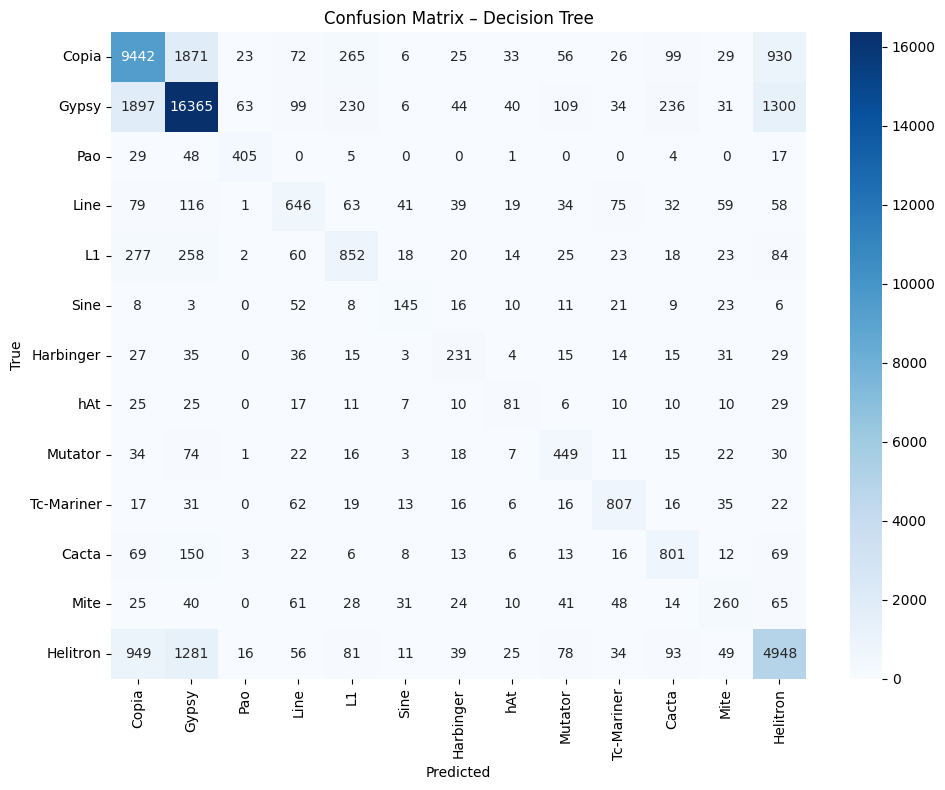

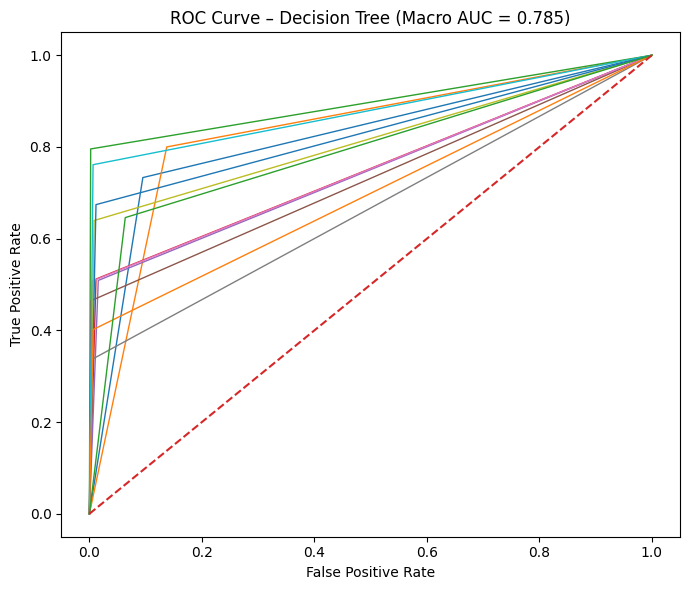

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    recall_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# -------------------------------------------------
# Configuration
# -------------------------------------------------
n_splits = 10
n_classes = 13

class_names = [
    'Copia','Gypsy','Pao','Line','L1','Sine','Harbinger',
    'hAt','Mutator','Tc-Mariner','Cacta','Mite','Helitron'
]

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# -------------------------------------------------
# Storage
# -------------------------------------------------
dt_acc_scores = []
dt_mcc_scores = []
dt_sen_scores = []
dt_spe_scores = []

dt_y_true_all = []
dt_y_pred_all = []
dt_y_prob_all = []

# -------------------------------------------------
# Cross-validation loop
# -------------------------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(feature, labels), 1):

    X_train, X_test = feature[train_idx], feature[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    dt = DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    )

    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)
    y_prob = dt.predict_proba(X_test)

    dt_y_true_all.append(y_test)
    dt_y_pred_all.append(y_pred)
    dt_y_prob_all.append(y_prob)

    dt_acc_scores.append(
        accuracy_score(y_test, y_pred)
    )

    dt_mcc_scores.append(
        matthews_corrcoef(y_test, y_pred)
    )

    dt_sen_scores.append(
        recall_score(y_test, y_pred, average='macro')
    )

    cm = confusion_matrix(y_test, y_pred)
    spec = []

    for i in range(n_classes):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec.append(tn / (tn + fp))

    dt_spe_scores.append(np.mean(spec))

# -------------------------------------------------
# Merge folds
# -------------------------------------------------
y_true = np.concatenate(dt_y_true_all)
y_pred = np.concatenate(dt_y_pred_all)
y_prob = np.vstack(dt_y_prob_all)

# -------------------------------------------------
# Performance summary
# -------------------------------------------------
print("Decision Tree – 10-Fold Cross-Validation Results")
print(f"Accuracy    : {np.mean(dt_acc_scores):.3f} ± {np.std(dt_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(dt_mcc_scores):.3f} ± {np.std(dt_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(dt_sen_scores):.3f} ± {np.std(dt_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(dt_spe_scores):.3f} ± {np.std(dt_spe_scores, ddof=1):.3f}")

# -------------------------------------------------
# Confusion Matrix
# -------------------------------------------------
cm_dt = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_dt, annot=True, fmt='g', cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Decision Tree")
plt.tight_layout()
plt.savefig("dt_crossval_cm.png", dpi=600)
plt.show()

# -------------------------------------------------
# ROC Curve
# -------------------------------------------------
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

roc_auc = []
plt.figure(figsize=(7, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc.append(auc(fpr, tpr))
    plt.plot(fpr, tpr, lw=1)

macro_auc_dt = np.mean(roc_auc)

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title(f"ROC Curve – Decision Tree (Macro AUC = {macro_auc_dt:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.savefig("dt_crossval_roc.png", dpi=600)
plt.show()

# -------------------------------------------------
# Save for statistical testing
# -------------------------------------------------
dt_results = {
    "mcc_scores": dt_mcc_scores,
    "macro_auc": macro_auc_dt
}


In [27]:
import numpy as np
from scipy.stats import ttest_rel

# ===============================
# MCC scores from 10-fold CV
# (These must already be computed)
# ===============================
models = {
    "XGBoost": xgb_mcc_scores,
    "Random Forest": rf_mcc_scores,
    "LightGBM": lgbm_mcc_scores,
    "Decision Tree": dt_mcc_scores
}

# ===============================
# Paired t-test function (MCC only)
# ===============================
def paired_ttest_mcc(model_a, model_b):
    scores_a = np.array(models[model_a])
    scores_b = np.array(models[model_b])

    t_stat, p_value = ttest_rel(scores_a, scores_b)

    mean_a = np.mean(scores_a)
    mean_b = np.mean(scores_b)

    if p_value < 0.05:
        winner = model_a if mean_a > mean_b else model_b
        conclusion = f"Statistically significant difference (p < 0.05); {winner} performs better"
    else:
        conclusion = "No statistically significant difference (p ≥ 0.05)"

    return {
        "Model A": model_a,
        "Model B": model_b,
        "Mean MCC A": mean_a,
        "Mean MCC B": mean_b,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Conclusion": conclusion
    }

# ===============================
# Run t-tests: XGBoost vs others
# ===============================
results = []

reference_model = "XGBoost"

for model in models:
    if model != reference_model:
        res = paired_ttest_mcc(reference_model, model)
        results.append(res)

# ===============================
# Print Results (Paper-ready)
# ===============================
for r in results:
    print("\n----------------------------------------")
    print(f"{r['Model A']} vs {r['Model B']}")
    print(f"Mean MCC ({r['Model A']}) = {r['Mean MCC A']:.4f}")
    print(f"Mean MCC ({r['Model B']}) = {r['Mean MCC B']:.4f}")
    print(f"t-statistic = {r['t-statistic']:.4f}")
    print(f"p-value     = {r['p-value']:.6f}")
    print("Conclusion:", r["Conclusion"])



----------------------------------------
XGBoost vs Random Forest
Mean MCC (XGBoost) = 0.7648
Mean MCC (Random Forest) = 0.6985
t-statistic = 38.3428
p-value     = 0.000000
Conclusion: Statistically significant difference (p < 0.05); XGBoost performs better

----------------------------------------
XGBoost vs LightGBM
Mean MCC (XGBoost) = 0.7648
Mean MCC (LightGBM) = 0.7430
t-statistic = 15.3205
p-value     = 0.000000
Conclusion: Statistically significant difference (p < 0.05); XGBoost performs better

----------------------------------------
XGBoost vs Decision Tree
Mean MCC (XGBoost) = 0.7648
Mean MCC (Decision Tree) = 0.6203
t-statistic = 93.0744
p-value     = 0.000000
Conclusion: Statistically significant difference (p < 0.05); XGBoost performs better


In [26]:
print("Decision Tree – 10-Fold Cross-Validation Results")
print(f"Accuracy    : {np.mean(dt_acc_scores):.3f} ± {np.std(dt_acc_scores, ddof=1):.3f}")
print(f"MCC         : {np.mean(dt_mcc_scores):.3f} ± {np.std(dt_mcc_scores, ddof=1):.3f}")
print(f"Sensitivity : {np.mean(dt_sen_scores):.3f} ± {np.std(dt_sen_scores, ddof=1):.3f}")
print(f"Specificity : {np.mean(dt_spe_scores):.3f} ± {np.std(dt_spe_scores, ddof=1):.3f}")

Decision Tree – 10-Fold Cross-Validation Results
Accuracy    : 0.722 ± 0.004
MCC         : 0.620 ± 0.005
Sensitivity : 0.599 ± 0.009
Specificity : 0.971 ± 0.000


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# -----------------------------------------
# Common FPR grid
# -----------------------------------------
mean_fpr = np.linspace(0, 1, 100)

# -----------------------------------------
# Helper function: mean macro ROC
# -----------------------------------------
def mean_macro_roc(fpr_dict, tpr_dict, n_classes):
    tpr_accumulator = np.zeros_like(mean_fpr)

    for fold in fpr_dict.keys():
        fold_tpr = np.zeros_like(mean_fpr)

        for c in range(n_classes):
            fold_tpr += np.interp(
                mean_fpr,
                fpr_dict[fold][c],
                tpr_dict[fold][c]
            )

        fold_tpr /= n_classes
        tpr_accumulator += fold_tpr

    mean_tpr = tpr_accumulator / len(fpr_dict)
    mean_auc = auc(mean_fpr, mean_tpr)

    return mean_tpr, mean_auc


# -----------------------------------------
# Number of classes (orders or superfamilies)
# -----------------------------------------
n_classes = 13   # change to 4 for order classification

# -----------------------------------------
# Compute mean ROC for each classifier
# -----------------------------------------
mean_tpr_rf, mean_auc_rf = mean_macro_roc(
    rf_order_fpr, rf_order_tpr, n_classes
)

mean_tpr_xgb, mean_auc_xgb = mean_macro_roc(
    xgb_order_fpr, xgb_order_tpr, n_classes
)

mean_tpr_lgbm, mean_auc_lgbm = mean_macro_roc(
    lgbm_order_fpr, lgbm_order_tpr, n_classes
)

mean_tpr_dt, mean_auc_dt = mean_macro_roc(
    dt_order_fpr, dt_order_tpr, n_classes
)

# -----------------------------------------
# Plot combined ROC curves
# -----------------------------------------
plt.figure(figsize=(8, 7))

plt.plot(mean_fpr, mean_tpr_rf,
         linewidth=2,
         label=f'Random Forest (AUC = {mean_auc_rf:.3f})')

plt.plot(mean_fpr, mean_tpr_xgb,
         linewidth=2,
         label=f'XGBoost (AUC = {mean_auc_xgb:.3f})')

plt.plot(mean_fpr, mean_tpr_lgbm,
         linewidth=2,
         label=f'LightGBM (AUC = {mean_auc_lgbm:.3f})')

plt.plot(mean_fpr, mean_tpr_dt,
         linewidth=2,
         label=f'Decision Tree (AUC = {mean_auc_dt:.3f})')

# Random classifier reference
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Averaged ROC Curves (10-Fold Cross-Validation)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.savefig('multiclass_crossval_combined_roc.png', dpi=600)
plt.show()

NameError: name 'rf_order_fpr' is not defined